# Credit Card Fraud

We will be detecting credit card fraud based on the different features of our dataset with 3 different models. Here is the Logistic Regression one.

We're looking to minimize the False Negative Rate or FNR.

Since the dataset is unbalanced, we can try two techniques that may help us have better predictions:

    - Adding some noise (gaussian) to the fraud data to create more and reduce the imbalance
    - Randomly sample the fraud data and train k models and average them out (or choose the best)
    
 

In [29]:
import numpy as np
import sklearn as sk
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import scale
import random

In [30]:
# May have to do this...
#!pip install imblearn
#!pip install --upgrade sklearn

In [31]:
df = pd.read_csv('creditcard.csv', low_memory=False)
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,140847.0,-0.851124,0.819195,2.014788,-0.634556,-0.166583,0.779931,-0.248282,0.440142,1.000038,...,0.133497,0.615617,-0.475375,0.010686,0.582486,-0.302416,0.486000,0.209563,2.84,0
1,55324.0,-1.957751,-0.290890,1.682625,-1.124376,0.444536,-1.083610,0.378358,-0.028458,-0.160319,...,-0.176952,-0.022638,0.638146,0.375206,0.088062,0.768010,0.180439,0.032899,21.50,0
2,156365.0,-0.611194,0.063762,-0.134807,-2.846052,2.334893,3.683796,-0.499824,1.074994,-1.227472,...,0.243298,0.524733,-0.447551,0.603589,0.699662,0.055948,0.068132,0.082477,19.95,0
3,41361.0,1.249868,-0.836290,1.481964,-0.439705,-1.992297,-0.644307,-1.207953,-0.008727,-0.282820,...,-0.122483,0.121404,0.085345,0.776665,-0.077777,1.091443,-0.003549,0.036796,37.90,0
4,77523.0,1.254985,0.262808,0.279808,0.705899,-0.484214,-1.103209,0.001771,-0.132512,0.222742,...,-0.301925,-0.932909,0.144289,0.310972,0.173479,0.098593,-0.031325,0.028160,1.98,0


In [32]:
frauds = df.loc[df['Class'] == 1]
non_frauds = df.loc[df['Class'] == 0]
print("We have", len(frauds), "fraud data points and", len(non_frauds), "nonfraudulent data points.")

We have 492 fraud data points and 284315 nonfraudulent data points.


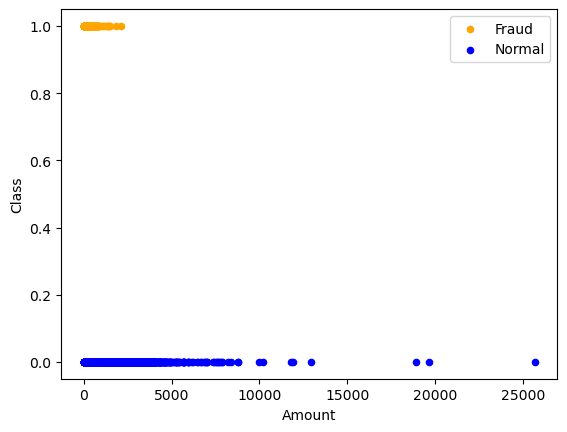

This feature looks important based on their distribution with respect to class.
We will now zoom in onto the fraud data to see the ranges of amount just for fun.


In [33]:
ax = frauds.plot.scatter(x='Amount', y='Class', color='Orange', label='Fraud')
non_frauds.plot.scatter(x='Amount', y='Class', color='Blue', label='Normal', ax=ax)
plt.show()
print("This feature looks important based on their distribution with respect to class.")
print("We will now zoom in onto the fraud data to see the ranges of amount just for fun.")

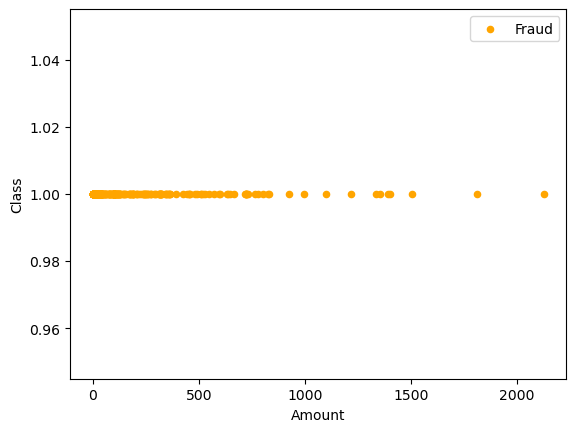

In [34]:
bx = frauds.plot.scatter(x='Amount', y='Class', color='Orange', label='Fraud')
plt.show()

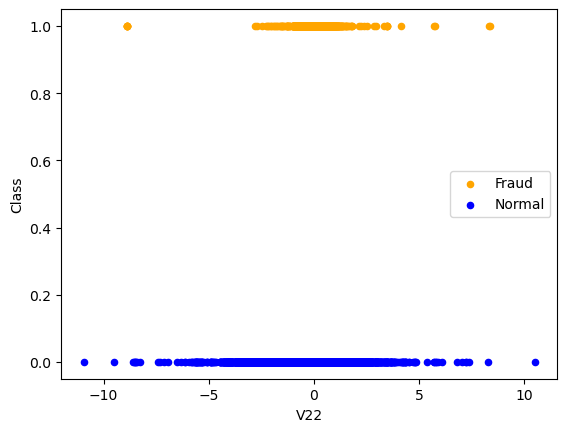

This feature may not be very important because of the similar distribution.


In [35]:
ax = frauds.plot.scatter(x='V22', y='Class', color='Orange', label='Fraud')
non_frauds.plot.scatter(x='V22', y='Class', color='Blue', label='Normal', ax=ax)
plt.show()
print("This feature may not be very important because of the similar distribution.")

# Logistic Regression (vanilla)

In [36]:
from sklearn import datasets, linear_model
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [37]:
X = df.iloc[:,:-1]
y = df['Class']

print("X and y sizes, respectively:", len(X), len(y))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35)
print("Train and test sizes, respectively:", len(X_train), len(y_train), "|", len(X_test), len(y_test))
print("Total number of frauds:", len(y.loc[df['Class'] == 1]), len(y.loc[df['Class'] == 1])/len(y))
print("Number of frauds on y_test:", len(y_test.loc[df['Class'] == 1]), len(y_test.loc[df['Class'] == 1]) / len(y_test))
print("Number of frauds on y_train:", len(y_train.loc[df['Class'] == 1]), len(y_train.loc[df['Class'] == 1])/len(y_train))

X and y sizes, respectively: 284807 284807
Train and test sizes, respectively: 185124 185124 | 99683 99683
Total number of frauds: 492 0.001727485630620034
Number of frauds on y_test: 174 0.0017455333406899874
Number of frauds on y_train: 318 0.0017177675503986518


In [38]:
logistic = linear_model.LogisticRegression(C=1e5)
logistic.fit(X_train, y_train)
print("Score: ", logistic.score(X_test, y_test))

Score:  0.9989165655126752


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [39]:
y_predicted = np.array(logistic.predict(X_test))
y_right = np.array(y_test)

Confusion matrix:
[[99472    37]
 [   71   103]]


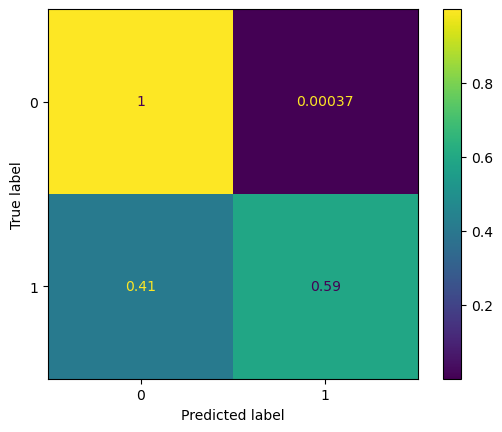

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     99509
           1       0.74      0.59      0.66       174

    accuracy                           1.00     99683
   macro avg       0.87      0.80      0.83     99683
weighted avg       1.00      1.00      1.00     99683



In [40]:
cm = confusion_matrix(y_right, y_predicted)
print("Confusion matrix:\n%s" % cm)
ConfusionMatrixDisplay.from_predictions(y_right, y_predicted, normalize='true')
plt.show()
print(classification_report(y_right, y_predicted))

In [41]:
fn, tp = cm[1,0], cm[1,1]
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
print("FNR is {0}".format(fnr))

FNR is 0.40804597701149425


# Logistic Regression with SMOTE over-sampling

In [42]:
sampler = SMOTE()
X_train_sampled, y_train_sampled = sampler.fit_resample(X_train, y_train)
print("Size of training set after over sampling:", len(X_train_sampled))

Size of training set after over sampling: 369612


In [43]:
# NOTE: Scaling makes it worse.
# X_train_sampled = scale(X_train_sampled)

logistic = linear_model.LogisticRegression(C=1e5)
logistic.fit(X_train_sampled, y_train_sampled)
print("Score: ", logistic.score(X_test, y_test))

Score:  0.9785018508672492


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Confusion matrix:
[[97385  2124]
 [   19   155]]


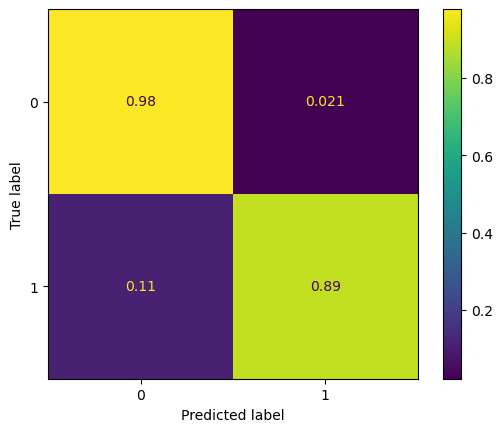

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     99509
           1       0.07      0.89      0.13       174

    accuracy                           0.98     99683
   macro avg       0.53      0.93      0.56     99683
weighted avg       1.00      0.98      0.99     99683



In [44]:
y_predicted1 = np.array(logistic.predict(X_test))
y_right1 = np.array(y_test)

cm1 = confusion_matrix(y_right1, y_predicted1)
print("Confusion matrix:\n%s" % cm1)
ConfusionMatrixDisplay.from_predictions(y_right1, y_predicted1, normalize='true')
plt.show()
print(classification_report(y_right1, y_predicted1))

In [45]:
fn1, tp1 = cm1[1,0], cm1[1,1]
fnr1 = fn1 / (fn1 + tp1) if (fn1 + tp1) > 0 else 0
print("FNR is {0}".format(fnr1))

FNR is 0.10919540229885058


# Logistic Regression with balanced class weights

In [46]:
best_c, best_fnr = 1, 1
for _ in range(20):
    c = random.uniform(1, 10000)
    logistic = linear_model.LogisticRegression(C=c, class_weight="balanced")
    logistic.fit(X_train, y_train)
    y_predicted2 = np.array(logistic.predict(X_test))
    y_right2 = np.array(y_test)
    cm2 = confusion_matrix(y_right2, y_predicted2)
    fn, tp = cm2[1,0], cm2[1,1]
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    if fnr < best_fnr:
        best_fnr = fnr
        best_c = c
print("Best C is {0} with best FNR of {1}.".format(best_c, best_fnr))

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Best C is 9601.31875432991 with best FNR of 0.06321839080459771.


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
